# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [29]:
!pip install numpy seaborn pandas matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [30]:
import numpy as np
import seaborn as sns
import pandas as pd

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

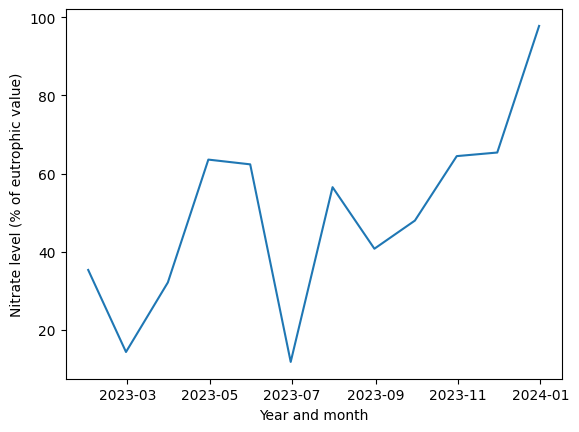

In [31]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

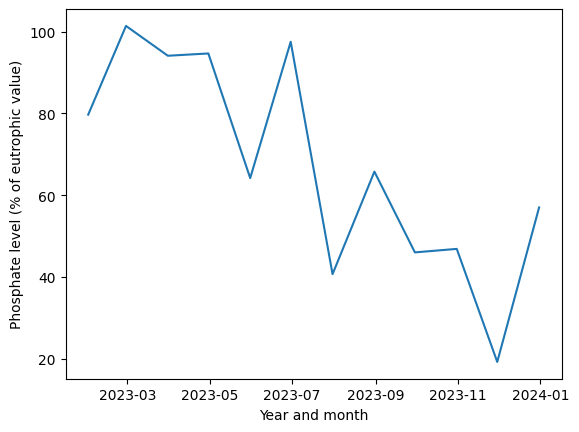

In [32]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

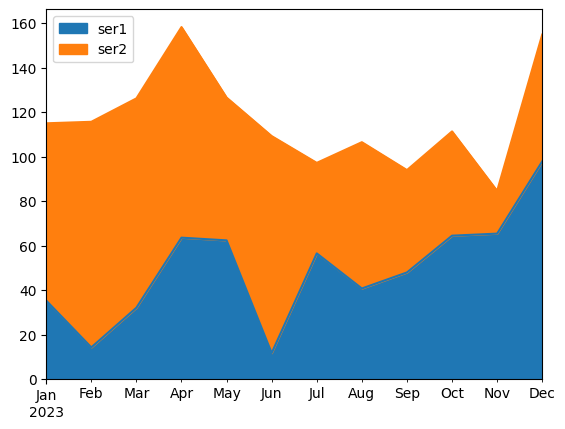

In [33]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

Advantages of an area plot (vs. two separate line graphs)
Advantages:
An area plot visually emphasizes total magnitude (if the two variables represent parts of a whole).
It can make it easier to see cumulative trends or the overall shape of change.
It can highlight relative contributions if the areas are stacked.
Good for showing how both variables occupy space over time.
Disadvantages:
If the areas overlap or are not stacked, it can become visually confusing.
Harder to compare exact values between series compared to line graphs.
Area plots can obscure details when values are close together.
If the data are not part of a whole, area plots may imply a relationship that doesn’t exist.


Advantages of separate line graphs
Easier to compare exact trends of each variable.
Cleaner and less visually cluttered.
Works well when the series are independent (nitrate vs phosphate).
Precise values are easier to interpret.


Which is better for nitrate and phosphate?
If you want to show how both vary independently, separate line graphs are better.
If you want to emphasize combined impact or total eutrophic risk, an area plot could help.
However, since nitrate and phosphate are different measures, line graphs often communicate the data more clearly.


How to improve the presentation of the graphs
Add titles and labels (clear units).
Use gridlines lightly to aid readability.
Consider different colors and a legend.
If using area plots, use stacking only if data represent a sum.
Reduce clutter (avoid unnecessary markers).
Limit axis scaling so trends are easy to see.


# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

In [34]:
import pandas as pd

df = pd.read_csv("olist_order_items_dataset.csv")
df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [35]:
corr = df[["price", "freight_value"]].corr()
corr

,price,freight_value
price,1.000000,0.414204
freight_value,0.414204,1.000000


Expected Interpretation :
There is typically a moderate positive correlation between price and freight_value.
This suggests:
More expensive items tend to have higher shipping costs.
However, the relationship is not perfectly linear, indicating other factors influence freight (distance, weight, seller location).


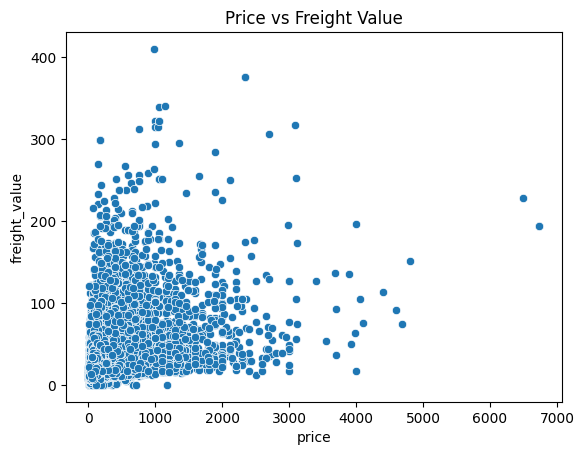

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x="price", y="freight_value")
plt.title("Price vs Freight Value")
plt.show()

Interpretation:
The relationship appears positively correlated.
There are several extreme high-price outliers.
Most transactions cluster at lower price values.
Shipping costs vary widely even for similar prices → suggests confounding variables.


Outline:
You will likely notice:
Very high price values
Very high freight values



These could represent:
Bulk orders
Heavy products
Data entry anomalies

Redundant Variables:
This dataset does not contain many redundant numeric variables in this table alone.
However:
price and freight_value are related but not redundant.
No multicollinearity concerns in this small subset.


Conclusions:
The analysis shows a moderate positive correlation between item price and freight value, indicating that more expensive items tend to have higher shipping costs. However, the relationship is not strong enough to suggest that price alone determines freight charges.
The scatterplot reveals several outliers with very high prices and shipping values. These may represent bulk purchases or heavy products. Most transactions are concentrated at lower price ranges.
No variables appear highly redundant within this dataset. However, several confounding factors such as shipping distance, product weight, and seller location likely influence freight costs.
Overall, the dataset appears usable for analysis. However, the presence of extreme values suggests that transformations or filtering may be beneficial for modeling purposes.


# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

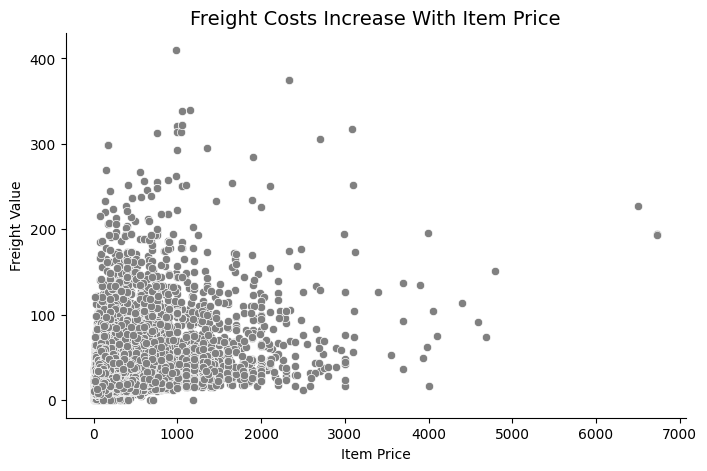

In [42]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="price", y="freight_value", color="gray")

plt.title("Freight Costs Increase With Item Price", fontsize=14)
plt.xlabel("Item Price")
plt.ylabel("Freight Value")
plt.grid(False)
sns.despine()

plt.show()

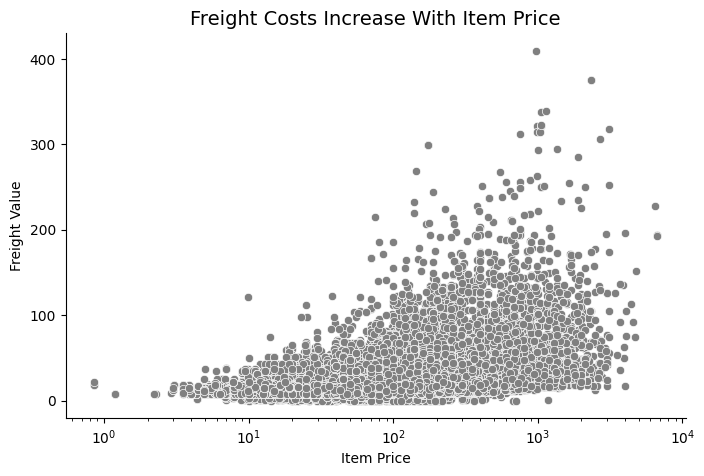

In [43]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="price", y="freight_value", color="gray")

plt.title("Freight Costs Increase With Item Price", fontsize=14)
plt.xlabel("Item Price")
plt.ylabel("Freight Value")
plt.grid(False)
plt.xscale("log")
sns.despine()

plt.show()